In [1]:
## Import all necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
## Select best Feature selection
def selectkbest(X, y, k):
    return SelectKBest(score_func=chi2, k=k).fit_transform(X, y)

In [3]:
## Test Train Split and Scaling
def split_and_scale(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test

In [4]:
## One Generic training function
def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)


In [5]:
## Add all the classifiers
models = {
    "Logistic": LogisticRegression(random_state=0),
    "SVMl": SVC(kernel="linear", random_state=0),
    "SVMnl": SVC(kernel="rbf", random_state=0),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Navie": GaussianNB(),
    "Decision": DecisionTreeClassifier(criterion="entropy", random_state=0),
    "Random": RandomForestClassifier(n_estimators=10, random_state=0)
}

In [6]:
## Load and prepare the data
df = pd.read_csv("prep.csv")
df = pd.get_dummies(df, drop_first=True)

X = df.drop("classification_yes", axis=1)
y = df["classification_yes"]

In [7]:
#Evaluate Accuracy vs K
results = []

max_k_allowed = X.shape[1]
k_range = range(1, max_k_allowed + 1)

for k in k_range:
    X_k = selectkbest(X, y, k)
    X_train, X_test, y_train, y_test = split_and_scale(X_k, y)
    
    accs = [k]
    for model in models.values():
        accs.append(train_and_evaluate(model, X_train, y_train, X_test, y_test))
    
    results.append(accs)

In [8]:
## Display the result Data frome
columns = ["Kvalue"] + list(models.keys())
results_df = pd.DataFrame(results, columns=columns)

In [11]:
results_df

,Kvalue,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random,MeanAccuracy
0,1,0.64,0.64,0.65,0.64,0.64,0.62,0.67,0.642857
1,2,0.75,0.69,0.73,0.77,0.74,0.72,0.75,0.735714
2,3,0.82,0.82,0.82,0.85,0.80,0.84,0.87,0.831429
3,4,0.85,0.82,0.83,0.86,0.79,0.89,0.90,0.848571
4,5,0.94,0.94,0.95,0.89,0.83,0.96,0.95,0.922857
5,6,0.95,0.96,0.96,0.93,0.89,0.97,0.99,0.950000
6,7,0.97,0.97,0.97,0.97,0.91,0.98,0.96,0.961429
7,8,0.97,0.97,0.97,0.98,0.91,0.95,0.96,0.958571
8,9,0.97,0.97,0.98,0.99,0.87,0.95,0.99,0.960000
9,10,0.99,0.98,1.00,0.99,0.92,0.96,0.99,0.975714


In [9]:
#Pick the Best K value automatically
results_df["MeanAccuracy"] = results_df.iloc[:, 1:].mean(axis=1)

best_k = int(results_df.loc[results_df["MeanAccuracy"].idxmax(), "Kvalue"])
print("Best k selected automatically:", best_k)

Best k selected automatically: 15


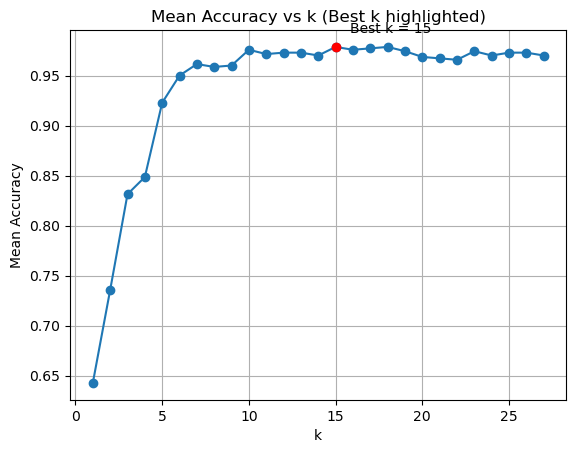

In [12]:
## Plot the Accuracy vs K value

plt.figure()
plt.plot(results_df["Kvalue"], results_df["MeanAccuracy"], marker="o")
plt.scatter(
    best_k,
    results_df["MeanAccuracy"].max(),
    color="red",
    zorder=5
)
plt.annotate(
    f"Best k = {best_k}",
    (best_k, results_df["MeanAccuracy"].max()),
    xytext=(10,10),
    textcoords="offset points"
)

plt.xlabel("k (Number of Features)")
plt.ylabel("Mean Accuracy")
plt.title("Mean Accuracy vs k (Best k highlighted)")
plt.grid(True)
plt.show()

In [ ]:
## Plotting the Best Kvalue
### Plotting the Best K value:

best_k = results_df.loc[results_df['MeanAccuracy'].idxmax(), 'Kvalue']
best_acc = results_df['MeanAccuracy'].max()

plt.figure()
plt.plot(results_df['Kvalue'], results_df['MeanAccuracy'], marker='o')
plt.scatter(best_k, best_acc, color='red', zorder=5)
plt.annotate(f'Best k = {best_k}',
             (best_k, best_acc),
             textcoords='offset points',
             xytext=(10,10))

plt.xlabel('k')
plt.ylabel('Mean Accuracy')
plt.title('Mean Accuracy vs k (Best k highlighted)')
plt.grid(True)
plt.show()